In [49]:
import pandas as pd
import json
import numpy as np
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import nltk
import re
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns

In [46]:
!pip install nrclex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.8 MB/s eta 0:00:00


In [47]:
from nrclex import NRCLex

In [34]:
df = pd.read_parquet("hf://datasets/AiresPucrs/tmdb-5000-movies/data/train-00000-of-00001-6db04ab1c75d6817.parquet")

In [20]:
df["keywords"].head()

,keywords
0,"[{""id"": 612, ""name"": ""hotel""}, {""id"": 613, ""na..."
1,"[{""id"": 803, ""name"": ""android""}, {""id"": 4270, ..."
2,"[{""id"": 494, ""name"": ""father son relationship""..."
3,"[{""id"": 422, ""name"": ""vietnam veteran""}, {""id""..."
4,"[{""id"": 255, ""name"": ""male nudity""}, {""id"": 29..."


In [35]:
def extract_names(json_str):
    try:
        items = json.loads(json_str) if isinstance(json_str, str) else json_str
        return ", ".join([item["name"] for item in items])
    except:
        return ""

df["keywords_clean"] = df["keywords"].apply(extract_names)

In [36]:
df["keywords_clean"].head()

,keywords_clean
0,"hotel, new year's eve, witch, bet, hotel room,..."
1,"android, galaxy, hermit, death star, lightsabe..."
2,"father son relationship, harbor, underwater, f..."
3,"vietnam veteran, hippie, mentally disabled, ru..."
4,"male nudity, female nudity, adultery, midlife ..."


In [10]:
df.columns

Index(['id', 'budget', 'genres', 'homepage', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count', 'cast', 'crew'],
      dtype='object')

In [6]:
df["tagline"].head()

,tagline
0,Twelve outrageous guests. Four scandalous requ...
1,"A long time ago in a galaxy far, far away..."
2,"There are 3.7 trillion fish in the ocean, they..."
3,"The world will never be the same, once you've ..."
4,Look closer.


In [37]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values("missing_pct", ascending=False)

print(missing[missing["missing_count"] > 0])

              missing_count  missing_pct
homepage               3091        64.36
tagline                 844        17.57
overview                  3         0.06
runtime                   2         0.04
release_date              1         0.02


In [38]:
cols_of_interest = ["overview", "tagline", "keywords", "genres", "original_language"]

maxLen = 0

for col in cols_of_interest:
    colLength = len(str(col))
    if colLength > maxLen:
      maxLen = colLength

for col in cols_of_interest:
    n = df[col].isnull().sum()
    pct = n / len(df) * 100
    colLength = len(str(col))
    dist = maxLen - colLength - len(str(n)) + 5
    print(f"{col}: {n} {"-" * dist} ({pct:.1f}%)")

overview: 3 ------------- (0.1%)
tagline: 844 ------------ (17.6%)
keywords: 0 ------------- (0.0%)
genres: 0 --------------- (0.0%)
original_language: 0 ---- (0.0%)


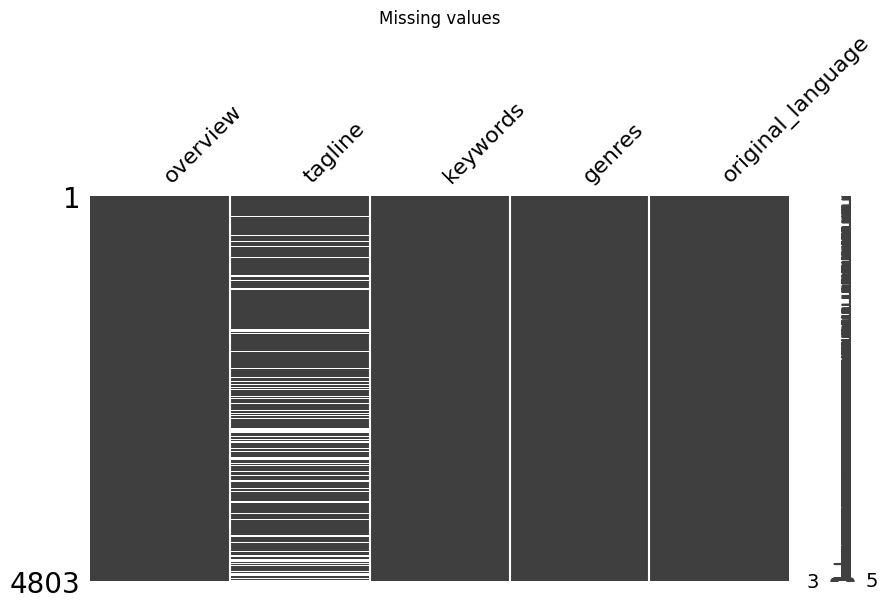

In [39]:
msno.matrix(df[cols_of_interest], figsize=(10, 5))
plt.title("Missing values")
plt.show()

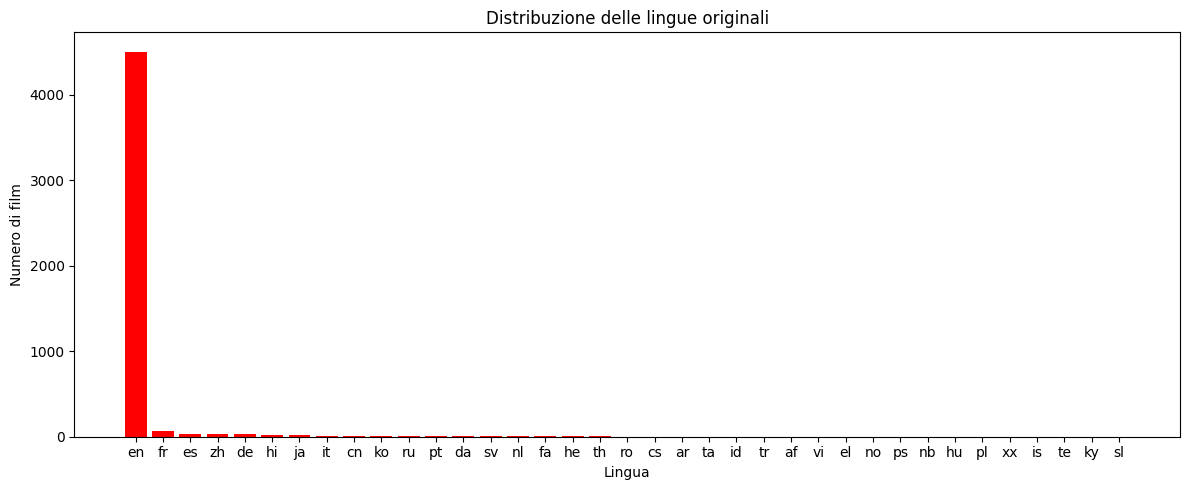

In [44]:
lang_counts = df["original_language"].value_counts()


fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(lang_counts.index, lang_counts.values, color="red")
ax.set_xlabel("Lingua")
ax.set_ylabel("Numero di film")
ax.set_title("Distribuzione delle lingue originali")
plt.tight_layout()
plt.show()


In [45]:
sample = df[df["original_language"] != "en"][["title", "original_language", "overview"]].head(10)
print(sample.to_string())


                              title original_language                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              overview
7                        Metropolis                de                                                                                                                                                                                                                                                                   In a futuristic city sharply divided between the working class and the city planners, the son of the city's mastermind falls in love with a working 

In [56]:
language_map = {
    "en": "english",
    "de": "german",
    "es": "spanish",
    "zh": "chinese",
    "ja": "japanese",
    "fr": "french",
    "da": "danish",
    "it": "italian",
    "sv": "swedish",
    "hi": "hindi",
    "ru": "russian",
    "pt": "portuguese",
    "ko": "korean",
    "af": "afrikaans",
    "ro": "romanian",
    "nl": "dutch",
    "ar": "arabic",
    "he": "hebrew",
    "th": "thai",
    "cn": "chinese",
    "tr": "turkish",
    "cs": "czech",
    "fa": "persian",
    "no": "norwegian",
    "ps": "pashto",
    "vi": "vietnamese",
    "el": "greek",
    "hu": "hungarian",
    "nb": "norwegian",
    "xx": "",
    "id": "indonesian",
    "pl": "polish",
    "is": "icelandic",
    "te": "telugu",
    "ta": "tamil",
    "ky": "kyrgyz",
    "sl": "slovenian",
}

In [58]:
df["language_clean"] = df["original_language"].map(language_map).fillna("")

df["genres_clean"] = df["genres"].apply(extract_names)

df["keywords_clean"] = df["keywords"].apply(extract_names)

df["tagline"] = df["tagline"].fillna("N/D")

In [72]:
nltk.download("stopwords", quiet=True)
nltk.download('wordnet')
nltk.download('punkt_tab')
STOPWORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
EMOTIONS = ["fear", "anger", "anticipation", "surprise", "sadness", "joy", "disgust", "positive", "negative"]

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [69]:
def get_emotions(text):
    obj = NRCLex("placeholder")
    obj.load_raw_text(text)
    emo = obj.affect_frequencies
    return pd.Series({e: emo.get(e, 0.0) for e in EMOTIONS})

def clean_and_lemm(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    tokens = [t for t in text.split() if t not in STOPWORDS]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

In [70]:
df["combined"] = (
    df["keywords_clean"].fillna("") + " " +
    df["tagline"].fillna("") + " " +
    df["genres_clean"] + " " +
    df["production_countries"].fillna("") + " " +
    df["language_clean"].fillna("")
)

df["sentiment"] = (
    df["overview"].fillna("") + " " +
    df["genres_clean"] + " " +
    df["keywords_clean"]
)

In [73]:
df["sentiment_lemm"] = df["sentiment"].apply(clean_and_lemm)
df[EMOTIONS] = df["sentiment_lemm"].apply(get_emotions)

In [74]:
df[EMOTIONS].head()

,fear,anger,anticipation,surprise,sadness,joy,disgust,positive,negative
0,0.166667,0.166667,0.000000,0.083333,0.000000,0.000000,0.083333,0.083333,0.333333
1,0.126761,0.112676,0.098592,0.056338,0.056338,0.084507,0.056338,0.197183,0.098592
2,0.055556,0.083333,0.138889,0.055556,0.055556,0.083333,0.000000,0.166667,0.166667
3,0.118644,0.050847,0.050847,0.033898,0.084746,0.152542,0.000000,0.254237,0.118644
4,0.071429,0.035714,0.142857,0.000000,0.142857,0.107143,0.035714,0.178571,0.178571


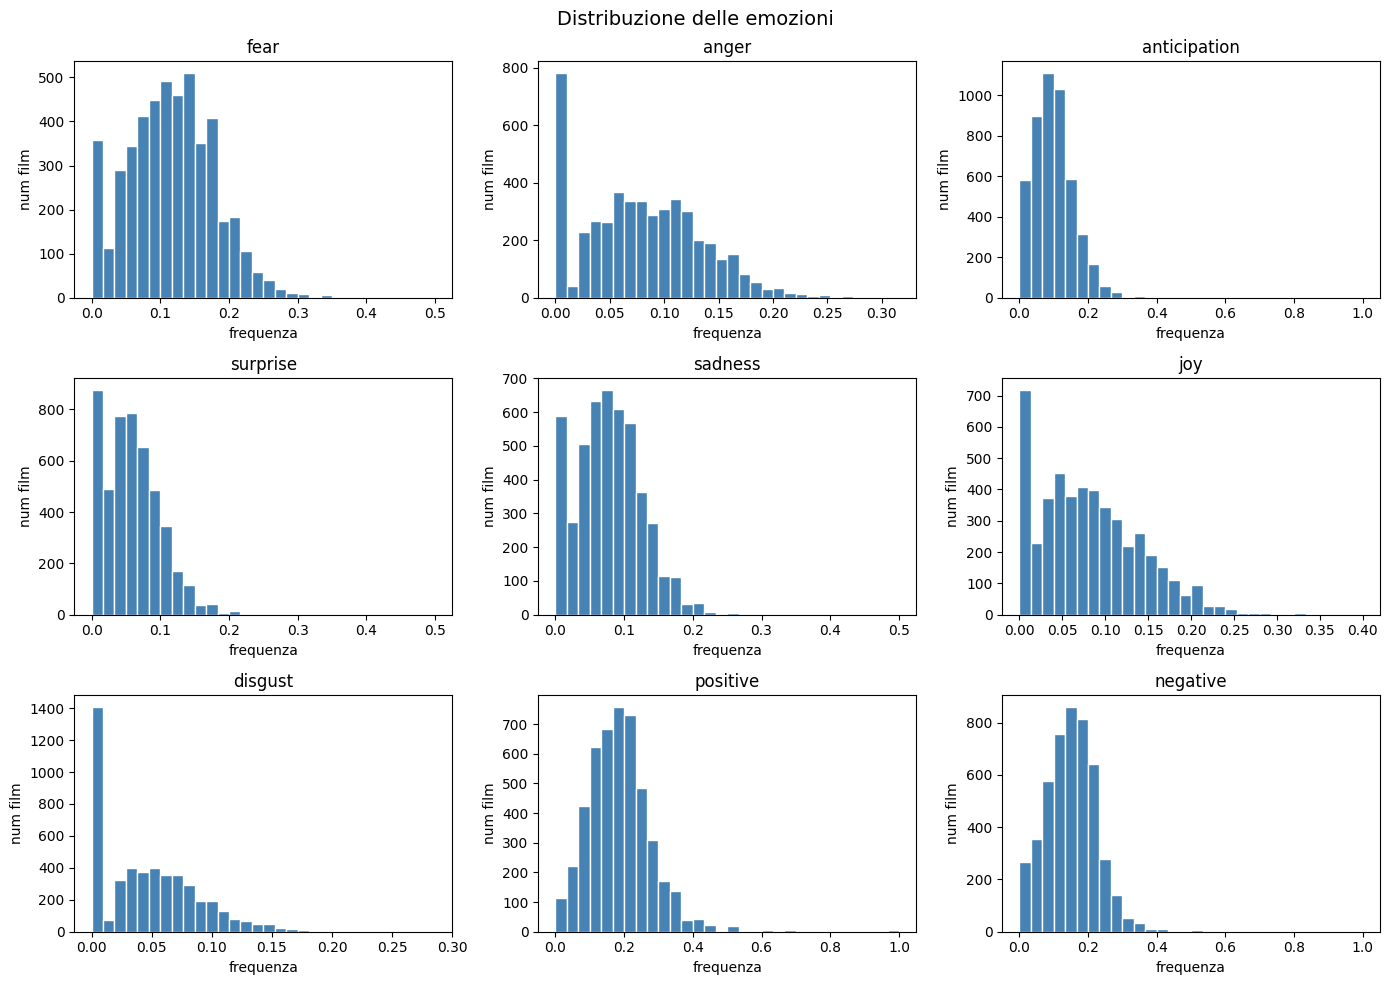

In [75]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, emo in enumerate(EMOTIONS):
    axes[i].hist(df[emo], bins=30, color="steelblue", edgecolor="white")
    axes[i].set_title(emo)
    axes[i].set_xlabel("frequenza")
    axes[i].set_ylabel("num film")

plt.suptitle("Distribuzione delle emozioni", fontsize=14)
plt.tight_layout()
plt.show()

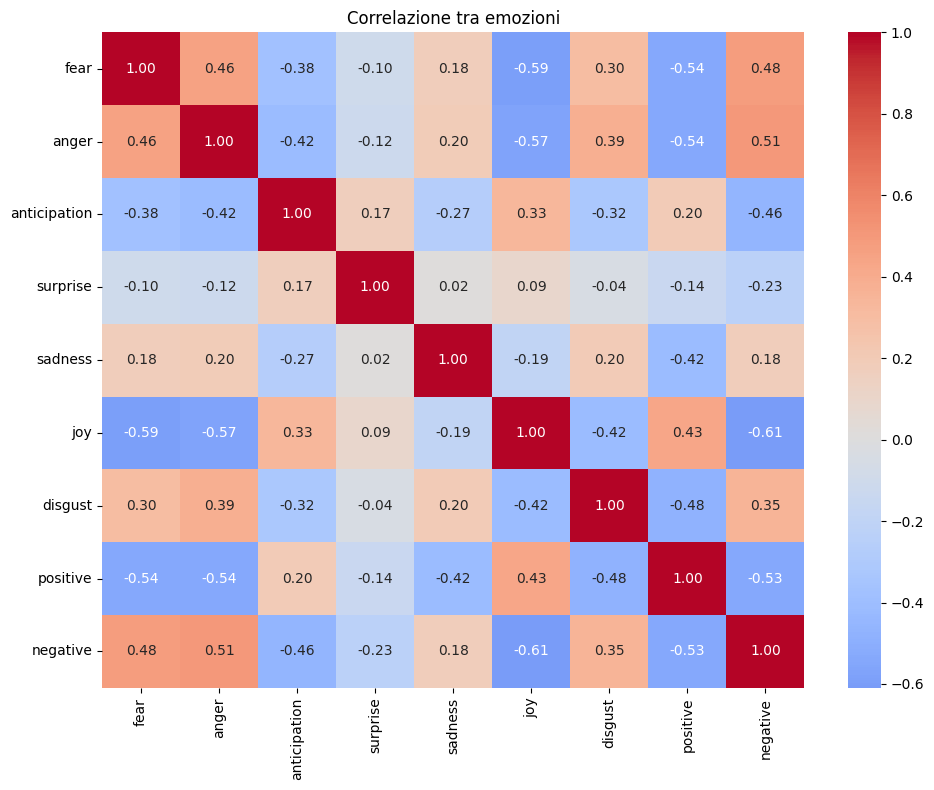

In [76]:
corr = df[EMOTIONS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlazione tra emozioni")
plt.tight_layout()
plt.show()

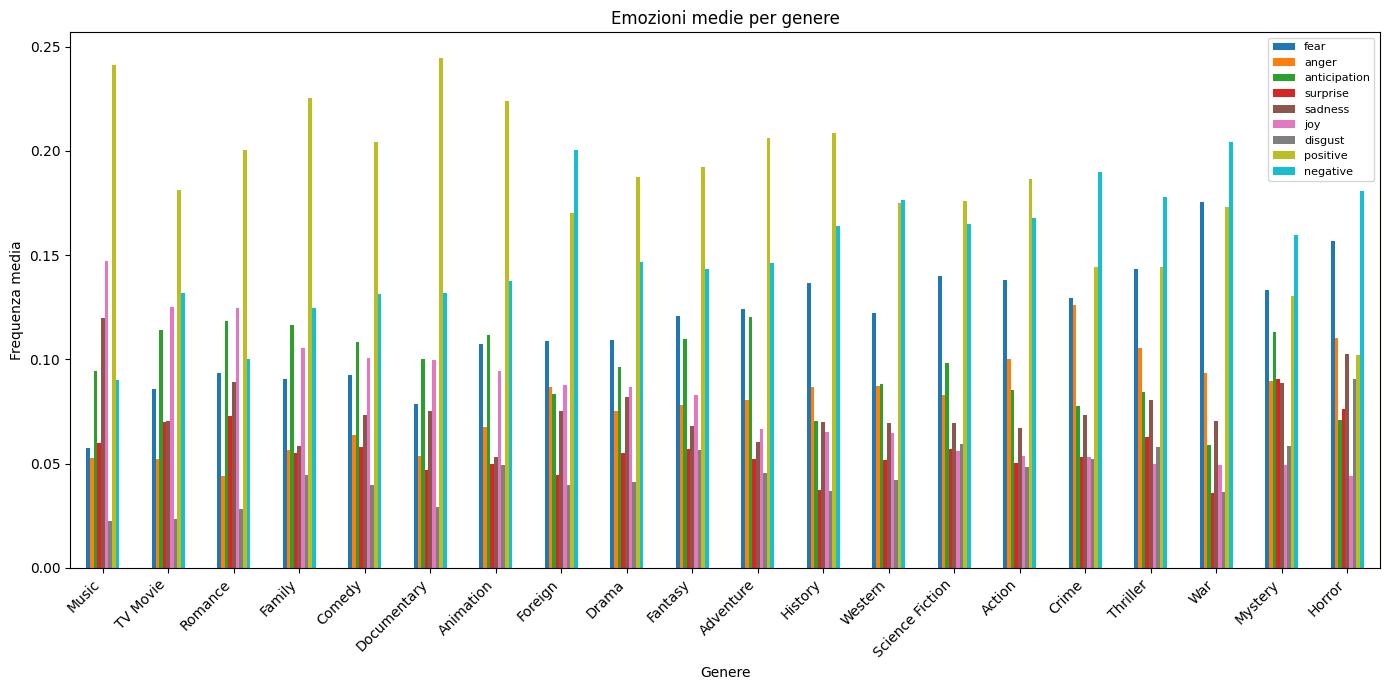

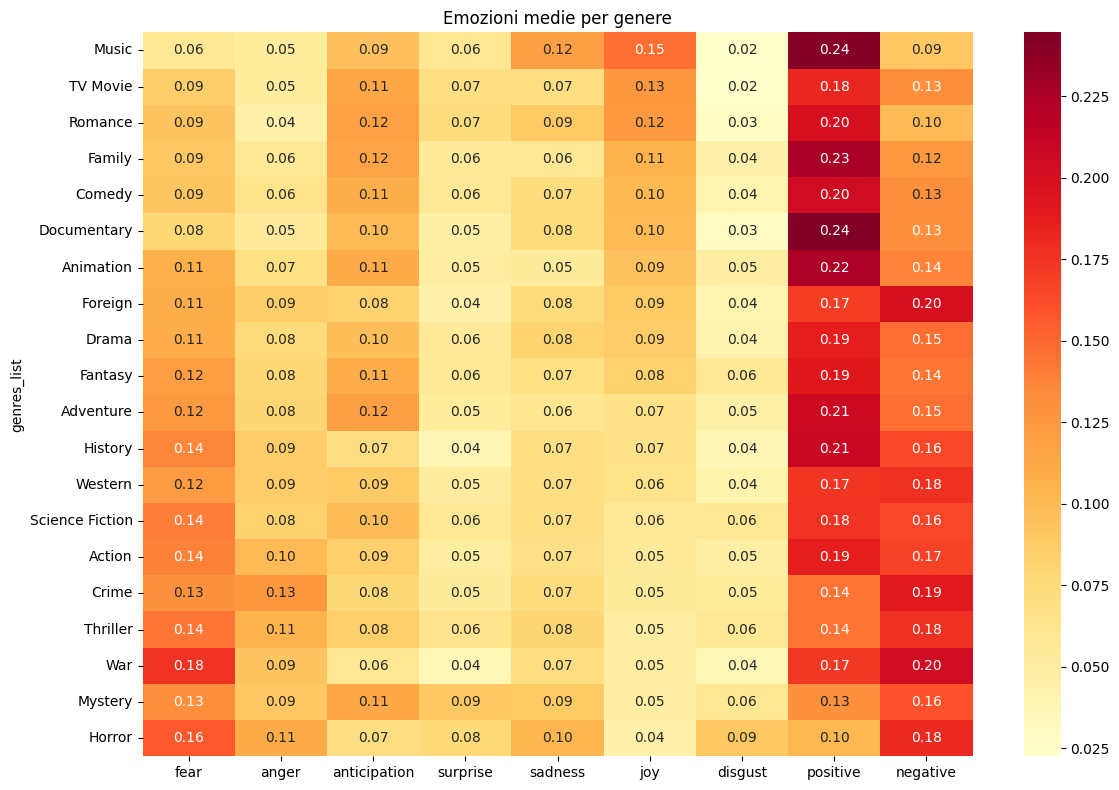

In [79]:
df_genres = df.copy()
df_genres["genres_list"] = df_genres["genres_clean"].str.split(", ")
df_exploded = df_genres.explode("genres_list")
df_exploded = df_exploded[df_exploded["genres_list"].notna() & (df_exploded["genres_list"] != "")]

genre_emotions = df_exploded.groupby("genres_list")[EMOTIONS].mean().sort_values("joy", ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
genre_emotions.plot(kind="bar", ax=ax, colormap="tab10")
ax.set_title("Emozioni medie per genere")
ax.set_xlabel("Genere")
ax.set_ylabel("Frequenza media")
ax.legend(loc="upper right", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(genre_emotions, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
ax.set_title("Emozioni medie per genere")
plt.tight_layout()
plt.show()

In [83]:
EMOTIONS = ["fear", "anger", "anticipation", "surprise", "sadness", "joy", "disgust"]

df = df.drop(columns=EMOTIONS)

df[EMOTIONS] = df["sentiment_lemm"].apply(get_emotions)

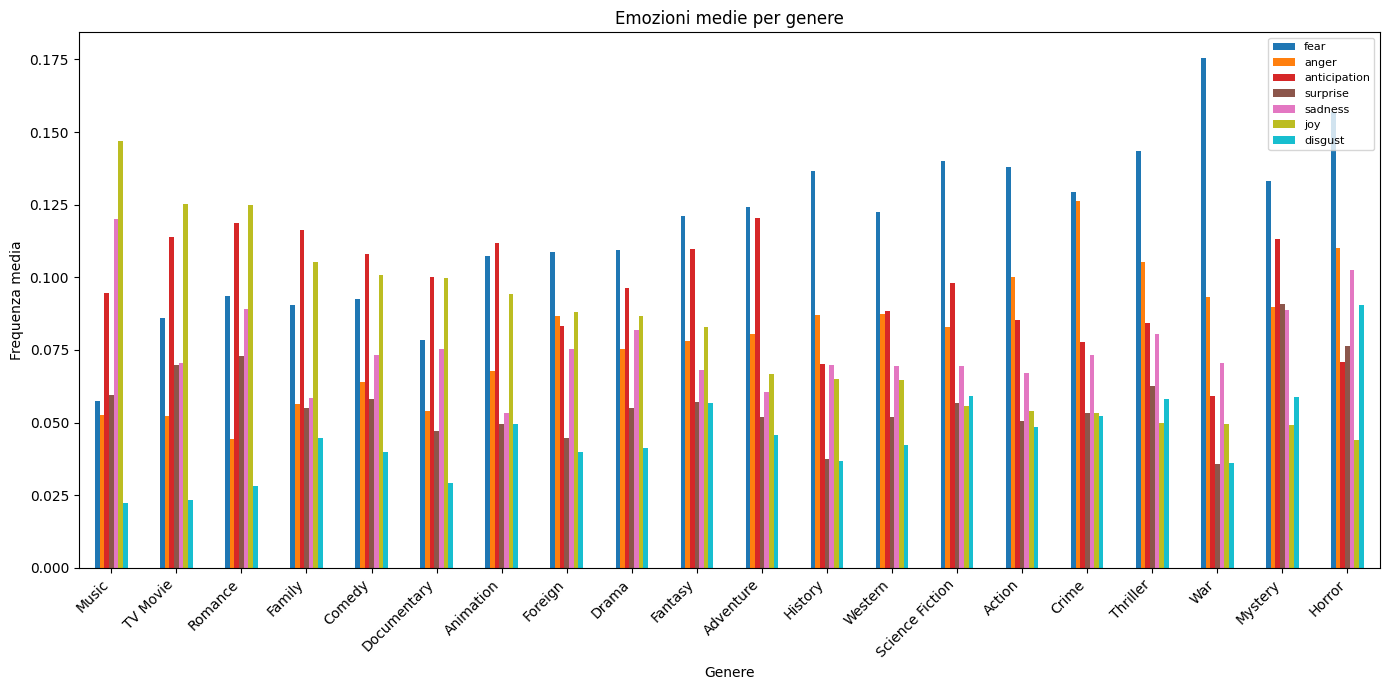

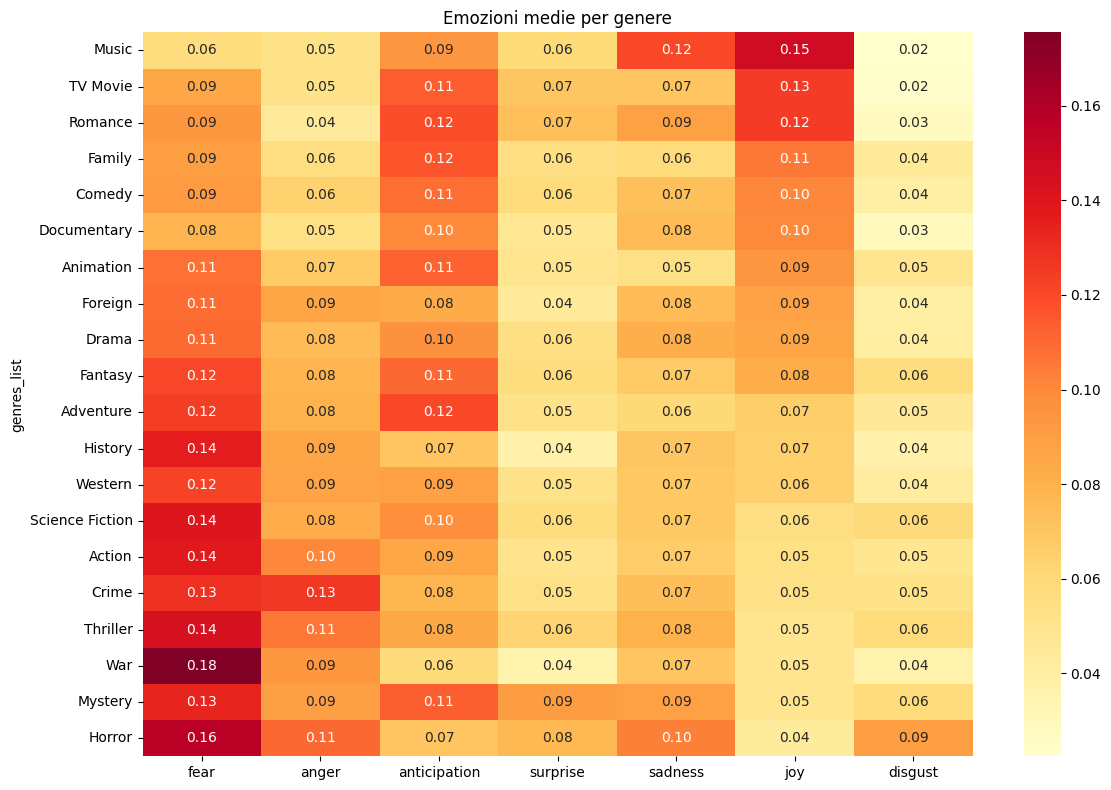

In [84]:
df_genres = df.copy()
df_genres["genres_list"] = df_genres["genres_clean"].str.split(", ")
df_exploded = df_genres.explode("genres_list")
df_exploded = df_exploded[df_exploded["genres_list"].notna() & (df_exploded["genres_list"] != "")]

genre_emotions = df_exploded.groupby("genres_list")[EMOTIONS].mean().sort_values("joy", ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
genre_emotions.plot(kind="bar", ax=ax, colormap="tab10")
ax.set_title("Emozioni medie per genere")
ax.set_xlabel("Genere")
ax.set_ylabel("Frequenza media")
ax.legend(loc="upper right", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(genre_emotions, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
ax.set_title("Emozioni medie per genere")
plt.tight_layout()
plt.show()

In [86]:
for emo in EMOTIONS:
    threshold = df[emo].quantile(0.99)  # top 1%
    outliers = df[df[emo] >= threshold][["title", emo]].sort_values(emo, ascending=False).head(5)
    print(f"\nTop 5 film per '{emo}':")
    print(outliers.to_string(index=False))


Top 5 film per 'fear':
                           title     fear
           Journey from the Fall 0.500000
Mongol: The Rise of Genghis Khan 0.375000
                        Redacted 0.375000
                         Skyline 0.363636
      The World's Fastest Indian 0.333333

Top 5 film per 'anger':
                     title    anger
                Straw Dogs 0.315789
            Identity Thief 0.285714
         Deadline - U.S.A. 0.285714
                       Hop 0.285714
The Taking of Pelham 1 2 3 0.272727

Top 5 film per 'anticipation':
                              title  anticipation
                          Boat Trip      1.000000
The Imaginarium of Doctor Parnassus      0.625000
                            Birdman      0.500000
                            Knowing      0.421053
                       Time Changer      0.416667

Top 5 film per 'surprise':
                          title  surprise
                  The Naked Ape  0.500000
       The Lizzie McGuire Movie  0.5000